<a href="https://colab.research.google.com/github/afyaana/HEARTATTACK_PREDICTION/blob/main/Heart_Attack_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROBLEM STATEMENT.

With HadHeartAttack as the prediction variable, the task would involve using other features in the dataset to predict whether a patient has experienced a heart attack. This could be approached as a binary classification problem, where the model learns patterns from the other variables to predict the likelihood of HadHeartAttack (0 for no, 1 for yes).


Heart disease is one of the leading causes of mortality worldwide, with heart attacks being a primary manifestation. Early detection and intervention can significantly reduce the risk and improve patient outcomes. In this project, we aim to develop a predictive model that leverages patient demographic, health, and lifestyle information to determine the likelihood of a heart attack occurrence. By analyzing this data, healthcare providers may gain insights into high-risk patients, enabling proactive measures and better allocation of medical resources.

The objective is to predict whether a patient has had a heart attack (binary outcome: HadHeartAttack) based on a range of features, including medical history, lifestyle habits, and demographic details. This model could serve as an assistive tool in clinical decision-making and help in implementing preventive healthcare strategies.

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df=pd.read_csv('/content/Patients Data ( Used for Heart Disease Prediction ).csv', encoding='latin1')
df

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1.0,"White only, Non-Hispanic",0.0,0.0,0.0,1.0,"No, did not receive any tetanus shot in the pa...",0.0,1.0
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0.0,"White only, Non-Hispanic",0.0,0.0,1.0,1.0,"Yes, received Tdap",0.0,0.0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0.0,"White only, Non-Hispanic",1.0,0.0,0.0,0.0,"Yes, received tetanus shot but not sure what type",0.0,0.0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0.0,"White only, Non-Hispanic",0.0,0.0,1.0,1.0,"Yes, received tetanus shot but not sure what type",0.0,0.0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1.0,"Black only, Non-Hispanic",0.0,0.0,1.0,0.0,"No, did not receive any tetanus shot in the pa...",0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16835,16836,California,Female,Very good,Age 40 to 44,1.65,90.720001,33.279999,0,0,...,Not at all (right now),0.0,Hispanic,0.0,1.0,0.0,0.0,"Yes, received Tdap",0.0,0.0
16836,16837,California,Female,Fair,Age 30 to 34,1.80,104.330002,32.080002,0,0,...,Not at all (right now),0.0,Hispanic,1.0,0.0,1.0,0.0,"No, did not receive any tetanus shot in the pa...",1.0,1.0
16837,16838,California,Female,Very good,Age 18 to 24,1.60,56.700001,22.139999,0,0,...,Not at all (right now),0.0,Hispanic,0.0,0.0,1.0,0.0,"No, did not receive any tetanus shot in the pa...",1.0,1.0
16838,16839,California,Female,Very good,Age 75 to 79,1.57,58.060001,23.410000,0,0,...,Never used e-cigarettes in my entire life,1.0,"White only, Non-Hispanic",1.0,1.0,1.0,1.0,"Yes, received tetanus shot but not sure what type",0.0,0.0


In [7]:
df.head()

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1.0,"White only, Non-Hispanic",0.0,0.0,0.0,1.0,"No, did not receive any tetanus shot in the pa...",0.0,1.0
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0.0,"White only, Non-Hispanic",0.0,0.0,1.0,1.0,"Yes, received Tdap",0.0,0.0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0.0,"White only, Non-Hispanic",1.0,0.0,0.0,0.0,"Yes, received tetanus shot but not sure what type",0.0,0.0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0.0,"White only, Non-Hispanic",0.0,0.0,1.0,1.0,"Yes, received tetanus shot but not sure what type",0.0,0.0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1.0,"Black only, Non-Hispanic",0.0,0.0,1.0,0.0,"No, did not receive any tetanus shot in the pa...",0.0,0.0


In [8]:
df.tail()

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
16835,16836,California,Female,Very good,Age 40 to 44,1.65,90.720001,33.279999,0,0,...,Not at all (right now),0.0,Hispanic,0.0,1.0,0.0,0.0,"Yes, received Tdap",0.0,0.0
16836,16837,California,Female,Fair,Age 30 to 34,1.80,104.330002,32.080002,0,0,...,Not at all (right now),0.0,Hispanic,1.0,0.0,1.0,0.0,"No, did not receive any tetanus shot in the pa...",1.0,1.0
16837,16838,California,Female,Very good,Age 18 to 24,1.60,56.700001,22.139999,0,0,...,Not at all (right now),0.0,Hispanic,0.0,0.0,1.0,0.0,"No, did not receive any tetanus shot in the pa...",1.0,1.0
16838,16839,California,Female,Very good,Age 75 to 79,1.57,58.060001,23.410000,0,0,...,Never used e-cigarettes in my entire life,1.0,"White only, Non-Hispanic",1.0,1.0,1.0,1.0,"Yes, received tetanus shot but not sure what type",0.0,0.0
16839,16840,California,Male,Good,Age 18 to 24,1.88,86.180000,24.389999,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16840 entries, 0 to 16839
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ÿPatientID                 16840 non-null  int64  
 1   State                      16840 non-null  object 
 2   Sex                        16840 non-null  object 
 3   GeneralHealth              16840 non-null  object 
 4   AgeCategory                16840 non-null  object 
 5   HeightInMeters             16840 non-null  float64
 6   WeightInKilograms          16840 non-null  float64
 7   BMI                        16840 non-null  float64
 8   HadHeartAttack             16840 non-null  int64  
 9   HadAngina                  16840 non-null  int64  
 10  HadStroke                  16840 non-null  int64  
 11  HadAsthma                  16840 non-null  int64  
 12  HadSkinCancer              16840 non-null  int64  
 13  HadCOPD                    16840 non-null  int

In [10]:
df.isnull().sum()

,0
ÿPatientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


In [11]:
df.duplicated().sum()

np.int64(0)

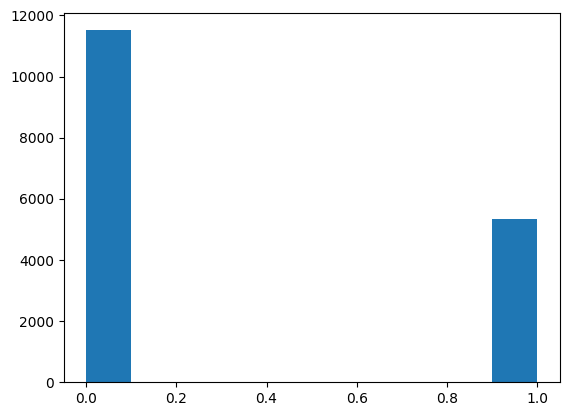

In [12]:
plt.hist(df["CovidPos"])
plt.show()

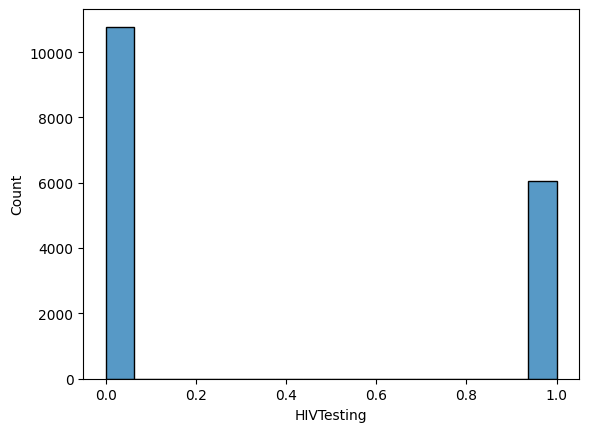

In [13]:
sns.histplot(df['HIVTesting'])
plt.show()

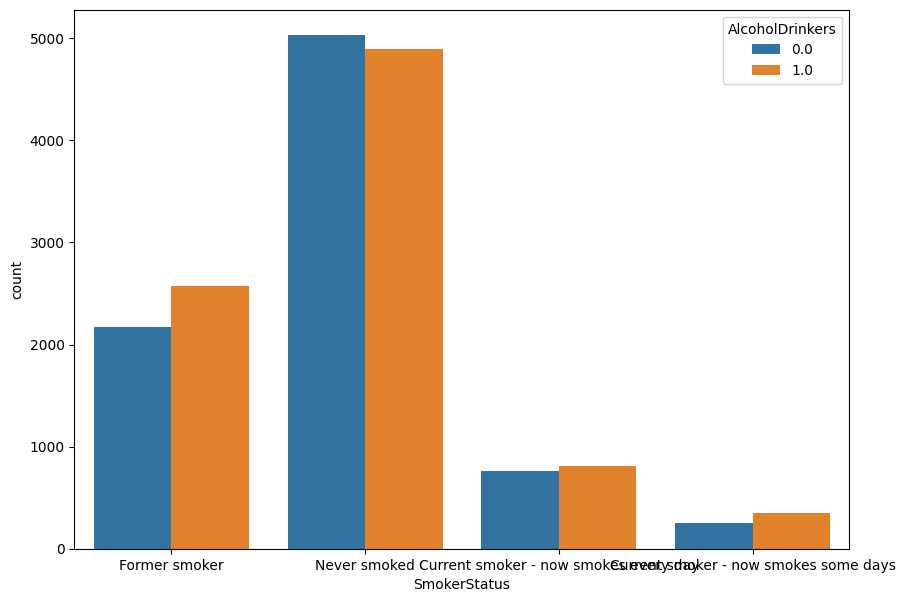

In [14]:
plt.figure(figsize=(10,7))
sns.countplot(data=df, x='SmokerStatus', hue='AlcoholDrinkers')
plt.show()

In [15]:
df.head()

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1.0,"White only, Non-Hispanic",0.0,0.0,0.0,1.0,"No, did not receive any tetanus shot in the pa...",0.0,1.0
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0.0,"White only, Non-Hispanic",0.0,0.0,1.0,1.0,"Yes, received Tdap",0.0,0.0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0.0,"White only, Non-Hispanic",1.0,0.0,0.0,0.0,"Yes, received tetanus shot but not sure what type",0.0,0.0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0.0,"White only, Non-Hispanic",0.0,0.0,1.0,1.0,"Yes, received tetanus shot but not sure what type",0.0,0.0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1.0,"Black only, Non-Hispanic",0.0,0.0,1.0,0.0,"No, did not receive any tetanus shot in the pa...",0.0,0.0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16840 entries, 0 to 16839
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ÿPatientID                 16840 non-null  int64  
 1   State                      16840 non-null  object 
 2   Sex                        16840 non-null  object 
 3   GeneralHealth              16840 non-null  object 
 4   AgeCategory                16840 non-null  object 
 5   HeightInMeters             16840 non-null  float64
 6   WeightInKilograms          16840 non-null  float64
 7   BMI                        16840 non-null  float64
 8   HadHeartAttack             16840 non-null  int64  
 9   HadAngina                  16840 non-null  int64  
 10  HadStroke                  16840 non-null  int64  
 11  HadAsthma                  16840 non-null  int64  
 12  HadSkinCancer              16840 non-null  int64  
 13  HadCOPD                    16840 non-null  int

In [17]:
df

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1.0,"White only, Non-Hispanic",0.0,0.0,0.0,1.0,"No, did not receive any tetanus shot in the pa...",0.0,1.0
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0.0,"White only, Non-Hispanic",0.0,0.0,1.0,1.0,"Yes, received Tdap",0.0,0.0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0.0,"White only, Non-Hispanic",1.0,0.0,0.0,0.0,"Yes, received tetanus shot but not sure what type",0.0,0.0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0.0,"White only, Non-Hispanic",0.0,0.0,1.0,1.0,"Yes, received tetanus shot but not sure what type",0.0,0.0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1.0,"Black only, Non-Hispanic",0.0,0.0,1.0,0.0,"No, did not receive any tetanus shot in the pa...",0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16835,16836,California,Female,Very good,Age 40 to 44,1.65,90.720001,33.279999,0,0,...,Not at all (right now),0.0,Hispanic,0.0,1.0,0.0,0.0,"Yes, received Tdap",0.0,0.0
16836,16837,California,Female,Fair,Age 30 to 34,1.80,104.330002,32.080002,0,0,...,Not at all (right now),0.0,Hispanic,1.0,0.0,1.0,0.0,"No, did not receive any tetanus shot in the pa...",1.0,1.0
16837,16838,California,Female,Very good,Age 18 to 24,1.60,56.700001,22.139999,0,0,...,Not at all (right now),0.0,Hispanic,0.0,0.0,1.0,0.0,"No, did not receive any tetanus shot in the pa...",1.0,1.0
16838,16839,California,Female,Very good,Age 75 to 79,1.57,58.060001,23.410000,0,0,...,Never used e-cigarettes in my entire life,1.0,"White only, Non-Hispanic",1.0,1.0,1.0,1.0,"Yes, received tetanus shot but not sure what type",0.0,0.0


In [18]:
df

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1.0,"White only, Non-Hispanic",0.0,0.0,0.0,1.0,"No, did not receive any tetanus shot in the pa...",0.0,1.0
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0.0,"White only, Non-Hispanic",0.0,0.0,1.0,1.0,"Yes, received Tdap",0.0,0.0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0.0,"White only, Non-Hispanic",1.0,0.0,0.0,0.0,"Yes, received tetanus shot but not sure what type",0.0,0.0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0.0,"White only, Non-Hispanic",0.0,0.0,1.0,1.0,"Yes, received tetanus shot but not sure what type",0.0,0.0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1.0,"Black only, Non-Hispanic",0.0,0.0,1.0,0.0,"No, did not receive any tetanus shot in the pa...",0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16835,16836,California,Female,Very good,Age 40 to 44,1.65,90.720001,33.279999,0,0,...,Not at all (right now),0.0,Hispanic,0.0,1.0,0.0,0.0,"Yes, received Tdap",0.0,0.0
16836,16837,California,Female,Fair,Age 30 to 34,1.80,104.330002,32.080002,0,0,...,Not at all (right now),0.0,Hispanic,1.0,0.0,1.0,0.0,"No, did not receive any tetanus shot in the pa...",1.0,1.0
16837,16838,California,Female,Very good,Age 18 to 24,1.60,56.700001,22.139999,0,0,...,Not at all (right now),0.0,Hispanic,0.0,0.0,1.0,0.0,"No, did not receive any tetanus shot in the pa...",1.0,1.0
16838,16839,California,Female,Very good,Age 75 to 79,1.57,58.060001,23.410000,0,0,...,Never used e-cigarettes in my entire life,1.0,"White only, Non-Hispanic",1.0,1.0,1.0,1.0,"Yes, received tetanus shot but not sure what type",0.0,0.0


In [19]:
print(df['State'].unique())

['Alabama' 'Alaska' 'Arizona' 'California' 'Arkansas' 'Connecticut'
 'Colorado' 'Delaware']


In [20]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['State']=le.fit_transform(df['State'])
df['Sex']=le.fit_transform(df['Sex'])
df['GeneralHealth']=le.fit_transform(df['GeneralHealth'])
df['ECigaretteUsage']=le.fit_transform(df['ECigaretteUsage'])
df['RaceEthnicityCategory']=le.fit_transform(df['RaceEthnicityCategory'])
df['SmokerStatus']=le.fit_transform(df['SmokerStatus'])
df['HadDiabetes']=le.fit_transform(df['HadDiabetes'])


In [21]:
df


,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,0,0,1,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,0,1.0,4,0.0,0.0,0.0,1.0,"No, did not receive any tetanus shot in the pa...",0.0,1.0
1,2,0,0,4,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,0,0.0,4,0.0,0.0,1.0,1.0,"Yes, received Tdap",0.0,0.0
2,3,0,1,0,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,0,0.0,4,1.0,0.0,0.0,0.0,"Yes, received tetanus shot but not sure what type",0.0,0.0
3,4,0,1,4,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,0,0.0,4,0.0,0.0,1.0,1.0,"Yes, received tetanus shot but not sure what type",0.0,0.0
4,5,0,0,2,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,0,1.0,0,0.0,0.0,1.0,0.0,"No, did not receive any tetanus shot in the pa...",0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16835,16836,4,0,4,Age 40 to 44,1.65,90.720001,33.279999,0,0,...,1,0.0,1,0.0,1.0,0.0,0.0,"Yes, received Tdap",0.0,0.0
16836,16837,4,0,1,Age 30 to 34,1.80,104.330002,32.080002,0,0,...,1,0.0,1,1.0,0.0,1.0,0.0,"No, did not receive any tetanus shot in the pa...",1.0,1.0
16837,16838,4,0,4,Age 18 to 24,1.60,56.700001,22.139999,0,0,...,1,0.0,1,0.0,0.0,1.0,0.0,"No, did not receive any tetanus shot in the pa...",1.0,1.0
16838,16839,4,0,4,Age 75 to 79,1.57,58.060001,23.410000,0,0,...,0,1.0,4,1.0,1.0,1.0,1.0,"Yes, received tetanus shot but not sure what type",0.0,0.0


In [22]:
print(df['AgeCategory'].unique())

['Age 75 to 79' 'Age 65 to 69' 'Age 60 to 64' 'Age 70 to 74'
 'Age 50 to 54' 'Age 80 or older' 'Age 55 to 59' 'Age 25 to 29'
 'Age 40 to 44' 'Age 30 to 34' 'Age 35 to 39' 'Age 18 to 24'
 'Age 45 to 49']


In [23]:
df['AgeCategory'].replace(['Age 75 to 79', 'Age 65 to 69' ,'Age 60 to 64', 'Age 70 to 74',
 'Age 50 to 54', 'Age 80 or older' ,'Age 55 to 59' ,'Age 25 to 29',
 'Age 40 to 44', 'Age 30 to 34', 'Age 35 to 39', 'Age 18 to 24',
 'Age 45 to 49'],[21,27,32,37,42,47,52,57,62,67,72,77,82.5],inplace=True)

/tmp/ipykernel_8239/1574715648.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AgeCategory'].replace(['Age 75 to 79', 'Age 65 to 69' ,'Age 60 to 64', 'Age 70 to 74',
/tmp/ipykernel_8239/1574715648.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['AgeCategory'].replace(['Age 75 to 79', 

In [24]:
print(df['RaceEthnicityCategory'].unique())

[4 0 3 2 1 5]


In [25]:
print(df['TetanusLast10Tdap'].unique())

['No, did not receive any tetanus shot in the past 10 years'
 'Yes, received Tdap' 'Yes, received tetanus shot but not sure what type'
 'Yes, received tetanus shot, but not Tdap' nan]


In [26]:
df['RaceEthnicityCategory'].unique()

array([4, 0, 3, 2, 1, 5])

In [27]:
df['RaceEthnicityCategory'].replace(["Black only, Non-Hispanic","Hispanic","Multiracial, Non-Hispanic","Other race only","White only, Non-Hispanic"],[1,2,3,4,5],inplace=True)


/tmp/ipykernel_8239/159812137.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['RaceEthnicityCategory'].replace(["Black only, Non-Hispanic","Hispanic","Multiracial, Non-Hispanic","Other race only","White only, Non-Hispanic"],[1,2,3,4,5],inplace=True)


In [28]:
df['TetanusLast10Tdap'].replace(["No, did not receive any tetanus shot in the past 10 years","Yes, received tetanus shot but not sure what type","Yes, received tetanus shot, but not Tdap","Yes, received Tdap"],[1,2,3,4],inplace=True)

/tmp/ipykernel_8239/3305168669.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TetanusLast10Tdap'].replace(["No, did not receive any tetanus shot in the past 10 years","Yes, received tetanus shot but not sure what type","Yes, received tetanus shot, but not Tdap","Yes, received Tdap"],[1,2,3,4],inplace=True)
/tmp/ipykernel_8239/3305168669.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=Fal

In [29]:
df

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,0,0,1,21.0,1.63,84.820000,32.099998,0,1,...,0,1.0,4,0.0,0.0,0.0,1.0,1.0,0.0,1.0
1,2,0,0,4,27.0,1.60,71.669998,27.990000,0,0,...,0,0.0,4,0.0,0.0,1.0,1.0,4.0,0.0,0.0
2,3,0,1,0,32.0,1.78,71.209999,22.530001,0,0,...,0,0.0,4,1.0,0.0,0.0,0.0,2.0,0.0,0.0
3,4,0,1,4,37.0,1.78,95.250000,30.129999,0,0,...,0,0.0,4,0.0,0.0,1.0,1.0,2.0,0.0,0.0
4,5,0,0,2,42.0,1.68,78.019997,27.760000,0,0,...,0,1.0,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16835,16836,4,0,4,62.0,1.65,90.720001,33.279999,0,0,...,1,0.0,1,0.0,1.0,0.0,0.0,4.0,0.0,0.0
16836,16837,4,0,1,67.0,1.80,104.330002,32.080002,0,0,...,1,0.0,1,1.0,0.0,1.0,0.0,1.0,1.0,1.0
16837,16838,4,0,4,77.0,1.60,56.700001,22.139999,0,0,...,1,0.0,1,0.0,0.0,1.0,0.0,1.0,1.0,1.0
16838,16839,4,0,4,21.0,1.57,58.060001,23.410000,0,0,...,0,1.0,4,1.0,1.0,1.0,1.0,2.0,0.0,0.0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16840 entries, 0 to 16839
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ÿPatientID                 16840 non-null  int64  
 1   State                      16840 non-null  int64  
 2   Sex                        16840 non-null  int64  
 3   GeneralHealth              16840 non-null  int64  
 4   AgeCategory                16840 non-null  float64
 5   HeightInMeters             16840 non-null  float64
 6   WeightInKilograms          16840 non-null  float64
 7   BMI                        16840 non-null  float64
 8   HadHeartAttack             16840 non-null  int64  
 9   HadAngina                  16840 non-null  int64  
 10  HadStroke                  16840 non-null  int64  
 11  HadAsthma                  16840 non-null  int64  
 12  HadSkinCancer              16840 non-null  int64  
 13  HadCOPD                    16840 non-null  int

In [31]:
df['HadDiabetes'].unique()

array([2, 0, 1, 3])

In [32]:
df['HadDiabetes'].replace(["No – no diabetes","No, pre-diabetes or borderline diabetes – some risk","Yes, but only during pregnancy (female) – temporary/conditional diabetes","Yes – diagnosed diabetes"],[1,2,3,4],inplace=True)

/tmp/ipykernel_8239/3114274560.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['HadDiabetes'].replace(["No – no diabetes","No, pre-diabetes or borderline diabetes – some risk","Yes, but only during pregnancy (female) – temporary/conditional diabetes","Yes – diagnosed diabetes"],[1,2,3,4],inplace=True)


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16840 entries, 0 to 16839
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ÿPatientID                 16840 non-null  int64  
 1   State                      16840 non-null  int64  
 2   Sex                        16840 non-null  int64  
 3   GeneralHealth              16840 non-null  int64  
 4   AgeCategory                16840 non-null  float64
 5   HeightInMeters             16840 non-null  float64
 6   WeightInKilograms          16840 non-null  float64
 7   BMI                        16840 non-null  float64
 8   HadHeartAttack             16840 non-null  int64  
 9   HadAngina                  16840 non-null  int64  
 10  HadStroke                  16840 non-null  int64  
 11  HadAsthma                  16840 non-null  int64  
 12  HadSkinCancer              16840 non-null  int64  
 13  HadCOPD                    16840 non-null  int

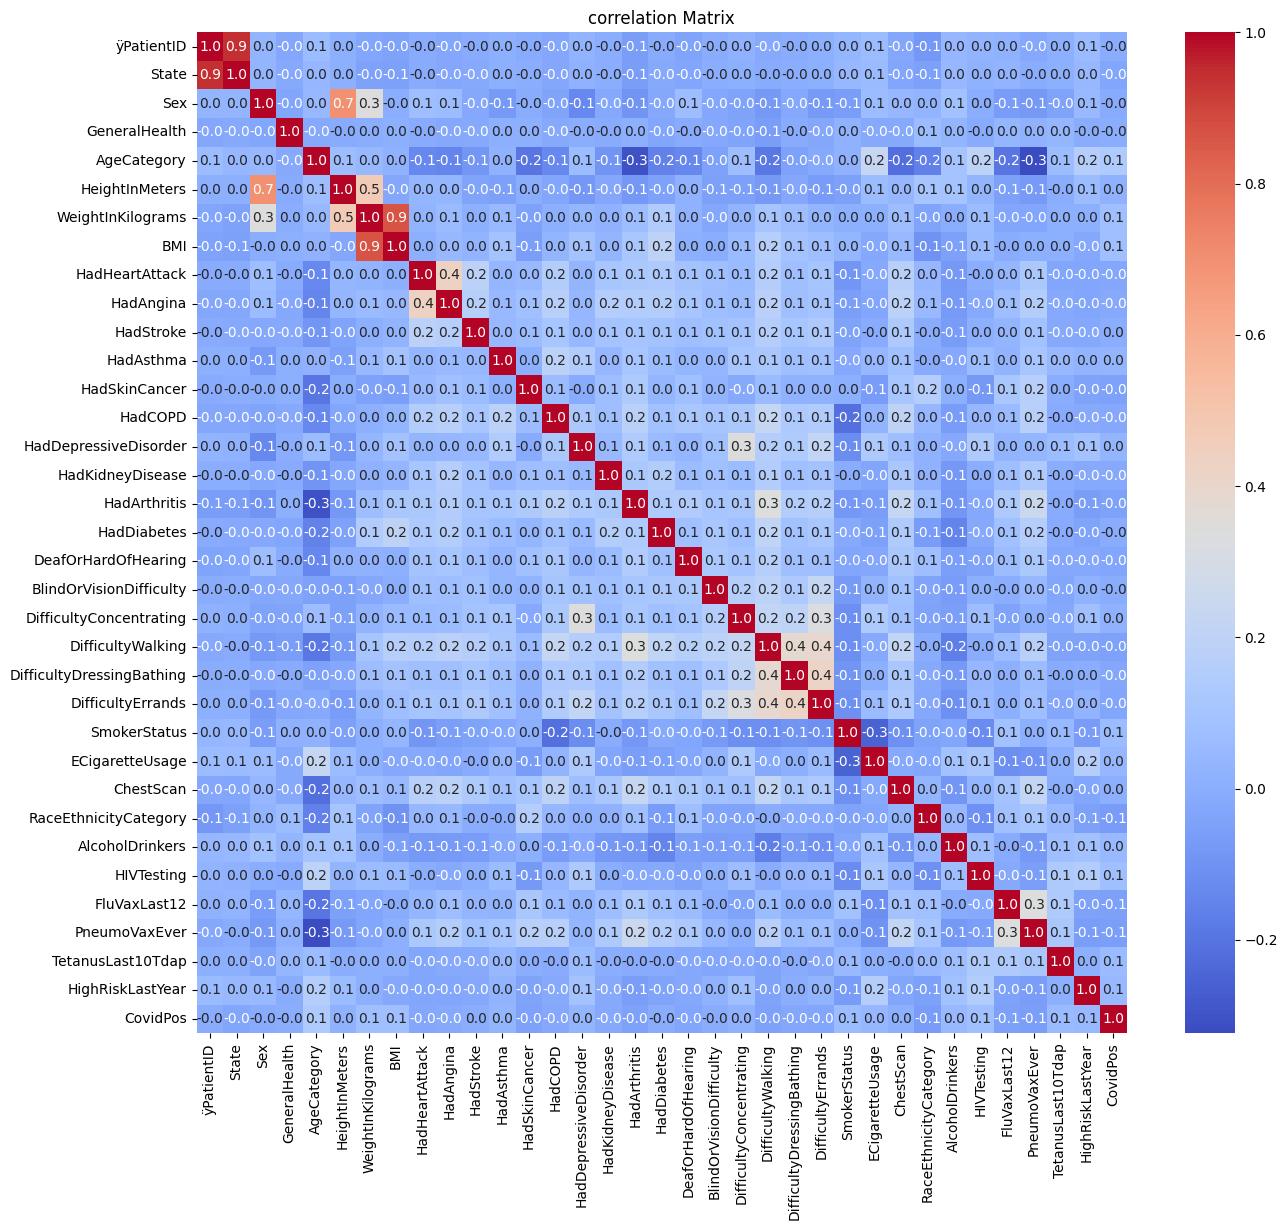

In [34]:
plt.figure(figsize=(15,13))
corr_matrix = df . corr()

sns.heatmap(corr_matrix,annot=True, fmt='0.01f', cmap='coolwarm')
plt.title('correlation Matrix')
plt.show()

In [35]:
df.drop(["State","WeightInKilograms","BMI"], axis=1,inplace=True)

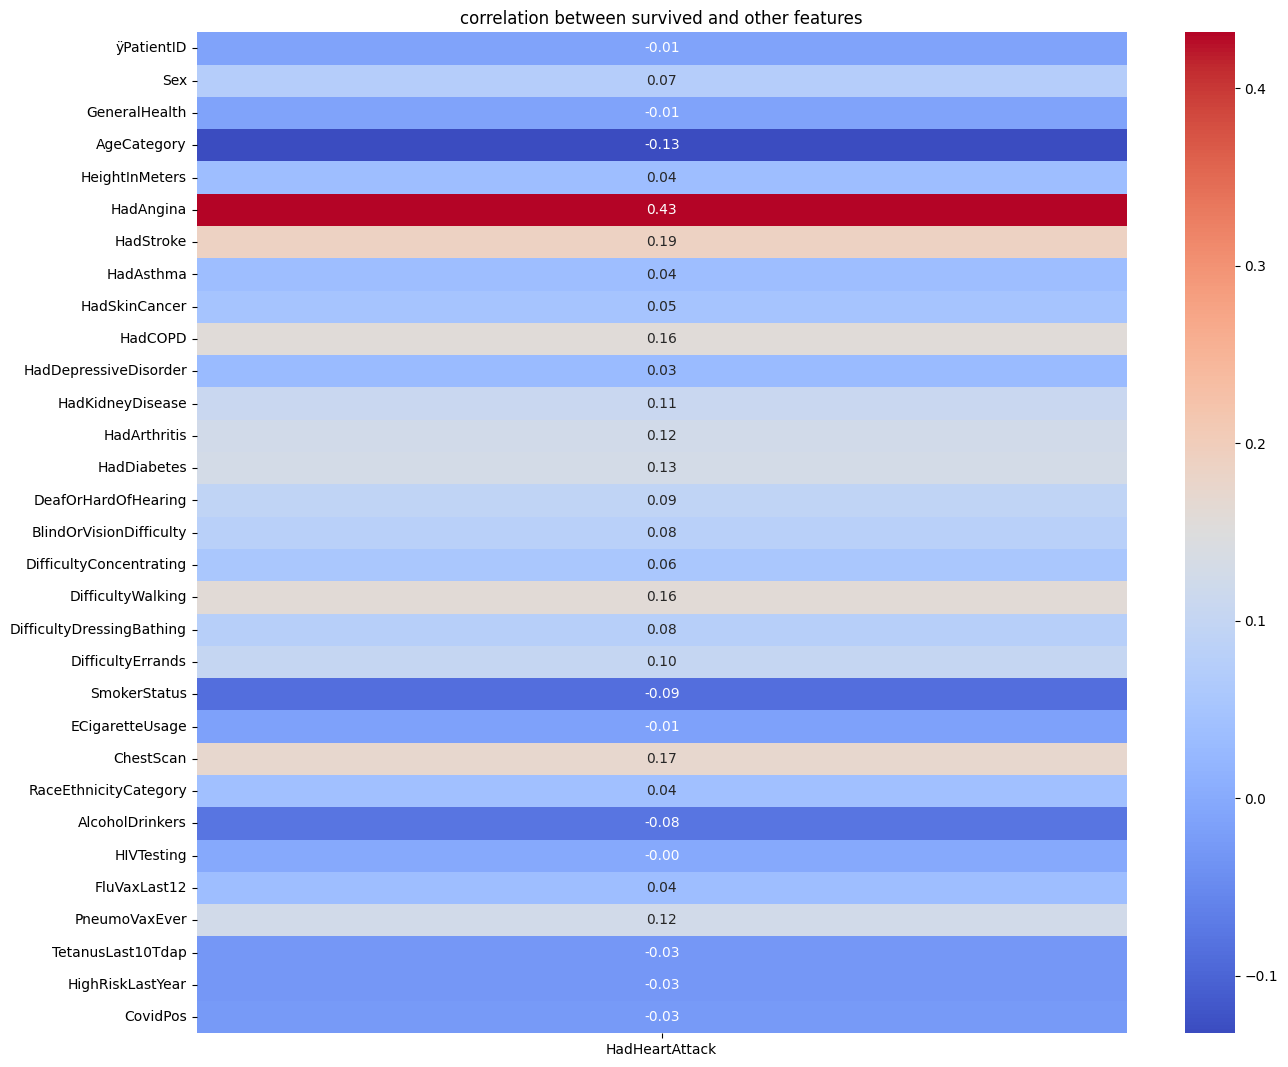

In [36]:
plt.figure(figsize=(15,13))
corr = df.corr()['HadHeartAttack']
corr = corr.drop('HadHeartAttack')
sns.heatmap(corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',cbar=True, annot_kws={'size':10})
plt.title('correlation between survived and other features')
plt.show()

In [37]:
df.drop(["Sex","AgeCategory","HadAngina","HadAsthma","HadCOPD","HadKidneyDisease","HadDiabetes","BlindOrVisionDifficulty","DifficultyWalking","DifficultyErrands","ECigaretteUsage","RaceEthnicityCategory","HIVTesting","PneumoVaxEver","HighRiskLastYear"],axis=1, inplace=True)

<Axes: >

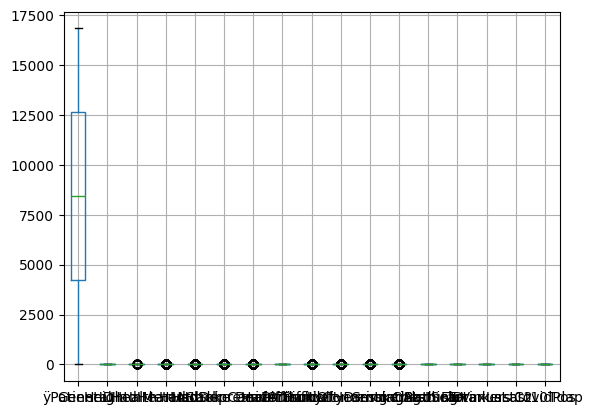

In [38]:
df.boxplot()

In [39]:
def remove_outliers_iqr(df, exclude_column):
    for col in df.columns:
      if col == exclude_column:
            continue
      Q1 = df[col].quantile(0.25)
      Q3 = df[col].quantile(0.75)
      IQR = Q3 - Q1
      lower_bound = Q1 - 1.5 * IQR
      upper_bound = Q3 + 1.5 * IQR
      df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df
df_cleaned = remove_outliers_iqr(df , exclude_column='HadHeartAttack')
df=df_cleaned

In [40]:
df.shape

(9131, 17)

In [41]:
df.head()

,ÿPatientID,GeneralHealth,HeightInMeters,HadHeartAttack,HadStroke,HadSkinCancer,HadDepressiveDisorder,HadArthritis,DeafOrHardOfHearing,DifficultyConcentrating,DifficultyDressingBathing,SmokerStatus,ChestScan,AlcoholDrinkers,FluVaxLast12,TetanusLast10Tdap,CovidPos
1,2,4,1.60,0,0,0,0,1,0,0,0,2,0.0,0.0,1.0,4.0,0.0
2,3,0,1.78,0,0,0,0,0,0,0,0,3,0.0,1.0,0.0,2.0,0.0
3,4,4,1.78,0,0,0,0,1,0,0,0,2,0.0,0.0,1.0,2.0,0.0
4,5,2,1.68,0,0,0,0,0,0,0,0,3,1.0,0.0,1.0,1.0,0.0
5,6,4,1.85,0,0,0,0,1,0,0,0,2,1.0,1.0,0.0,1.0,1.0


In [42]:
df.head

<bound method NDFrame.head of        ÿPatientID  GeneralHealth  HeightInMeters  HadHeartAttack  HadStroke  \
1               2              4            1.60               0          0   
2               3              0            1.78               0          0   
3               4              4            1.78               0          0   
4               5              2            1.68               0          0   
5               6              4            1.85               0          0   
...           ...            ...             ...             ...        ...   
16831       16832              4            1.88               0          0   
16833       16834              4            1.65               0          0   
16835       16836              4            1.65               0          0   
16836       16837              1            1.80               0          0   
16837       16838              4            1.60               0          0   

       HadSkinCancer  HadDepressiveDisorder  HadArthritis  \
1                  0                      0             1   
2                  0                      0             0   
3                  0                      0             1   
4                  0                      0             0   
5                  0                      0             1   
...              ...                    ...           ...   
16831              0                      0             0   
16833              0                      0             0   
16835              0                      0             0   
16836              0                      0             0   
16837              0                      0             0   

       DeafOrHardOfHearing  DifficultyConcentrating  \
1                        0                        0   
2                        0                        0   
3                        0                        0   
4                        0                        0   
5                        0                        0   
...                    ...                      ...   
16831                    0                        0   
16833                    0                        0   
16835                    0                        0   
16836                    0                        0   
16837                    0                        0   

       DifficultyDressingBathing  SmokerStatus  ChestScan  AlcoholDrinkers  \
1                              0             2        0.0              0.0   
2                              0             3        0.0              1.0   
3                              0             2        0.0              0.0   
4                              0             3        1.0              0.0   
5                              0             2        1.0              1.0   
...                          ...           ...        ...              ...   
16831                          0             3        0.0              1.0   
16833                          0             3        0.0              0.0   
16835                          0             3        0.0              0.0   
16836                          0             2        0.0              1.0   
16837                          0             3        0.0              0.0   

       FluVaxLast12  TetanusLast10Tdap  CovidPos  
1               1.0                4.0       0.0  
2               0.0                2.0       0.0  
3               1.0                2.0       0.0  
4               1.0                1.0       0.0  
5               0.0                1.0       1.0  
...             ...                ...       ...  
16831           0.0                4.0       0.0  
16833           0.0                4.0       0.0  
16835           0.0                4.0       0.0  
16836           1.0                1.0       1.0  
16837           1.0                1.0       1.0  

[9131 rows x 17 columns]>

In [43]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler



# Select the features that you want to scale
features = ['ÿPatientID','GeneralHealth','HeightInMeters','HadHeartAttack','HadStroke','HadSkinCancer','HadDepressiveDisorder','HadArthritis','DeafOrHardOfHearing','DifficultyConcentrating','DifficultyDressingBathing','SmokerStatus','ChestScan','AlcoholDrinkers','FluVaxLast12','TetanusLast10Tdap','CovidPos']

# create a MinMaxScaler object
scaler = MinMaxScaler()

# Fit the scaler to your data and transform it
scaled_data =scaler.fit_transform(df[features])

# Create a Dataframe from scaled_data with the correct column names
scaled_df = pd.DataFrame(scaled_data, columns=features)

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd
X = df[['ÿPatientID','GeneralHealth','HeightInMeters','HadHeartAttack','HadStroke','HadSkinCancer','HadDepressiveDisorder','HadArthritis','DeafOrHardOfHearing','DifficultyConcentrating','DifficultyDressingBathing','SmokerStatus','ChestScan','AlcoholDrinkers','FluVaxLast12','TetanusLast10Tdap','CovidPos']]
y = df['HadHeartAttack'].reset_index(drop=True)

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.25, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 1.00


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
